# EDA ECOMMERCE CHURN
## NOMBRE: CÉSAR MAYTA
## FUENTE : https://www.kaggle.com/datasets/upam22/ecommerce-customer-churn-data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("upam22/ecommerce-customer-churn-data")

print("Path to dataset files:", path)

100%|██████████| 90.7k/90.7k [00:00<00:00, 25.4MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/upam22/ecommerce-customer-churn-data/versions/1


In [3]:
!ls /root/.cache/kagglehub/datasets/upam22/ecommerce-customer-churn-data/versions/1

ecom_data.csv


In [4]:
PATH_CSV = path + "/ecom_data.csv"

In [5]:
%run '/content/pandas_missing_extension.ipynb'

In [6]:
data_df = pd.read_csv(PATH_CSV)
data_df

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,160
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,121
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,130
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5625,55626,0,10.0,Computer,1,30.0,Credit Card,Male,3.0,2,Laptop & Accessory,1,Married,6,0,18.0,1.0,2.0,4.0,151
5626,55627,0,13.0,Mobile Phone,1,13.0,Credit Card,Male,3.0,5,Fashion,5,Married,6,0,16.0,1.0,2.0,NaN,225
5627,55628,0,1.0,Mobile Phone,1,11.0,Debit Card,Male,3.0,2,Laptop & Accessory,4,Married,3,1,21.0,1.0,2.0,4.0,186
5628,55629,0,23.0,Computer,3,9.0,Credit Card,Male,4.0,5,Laptop & Accessory,4,Married,4,0,15.0,2.0,2.0,9.0,179


# EDA

In [7]:
data_df.dtypes

,0
CustomerID,int64
Churn,int64
Tenure,float64
PreferredLoginDevice,object
CityTier,int64
WarehouseToHome,float64
PreferredPaymentMode,object
Gender,object
HourSpendOnApp,float64
NumberOfDeviceRegistered,int64


In [8]:
data_df.dtypes.value_counts()

,count
int64,8
float64,7
object,5


# TRATAMIENTO DE NULOS

In [9]:
data_df = data_df.drop(['CustomerID','OrderCount'],axis=1)

In [10]:
data_df.missing.number_missing()

np.int64(1598)

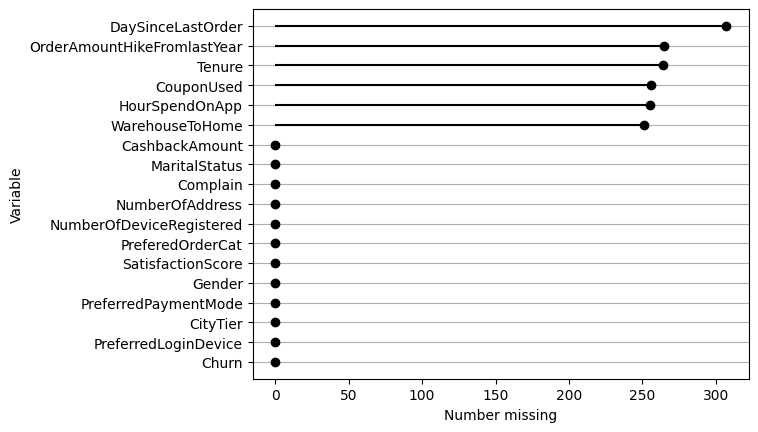

In [11]:
data_df.missing.missing_variable_plot()

# IMPUTACIÓN DE VARIABLES NÚMERICAS

In [12]:
data_df.dtypes

,0
Churn,int64
Tenure,float64
PreferredLoginDevice,object
CityTier,int64
WarehouseToHome,float64
PreferredPaymentMode,object
Gender,object
HourSpendOnApp,float64
NumberOfDeviceRegistered,int64
PreferedOrderCat,object


In [13]:
data_df.columns

Index(['Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier',
       'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp',
       'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore',
       'MaritalStatus', 'NumberOfAddress', 'Complain',
       'OrderAmountHikeFromlastYear', 'CouponUsed', 'DaySinceLastOrder',
       'CashbackAmount'],
      dtype='object')

In [14]:
numerics_nan = ['DaySinceLastOrder','OrderAmountHikeFromlastYear','Tenure','CouponUsed','HourSpendOnApp','WarehouseToHome']

In [15]:
df_cleaned = data_df.copy()

In [16]:
for variable in numerics_nan:
  df_cleaned[variable] = df_cleaned[variable].fillna(float(round(df_cleaned[variable].mean())))

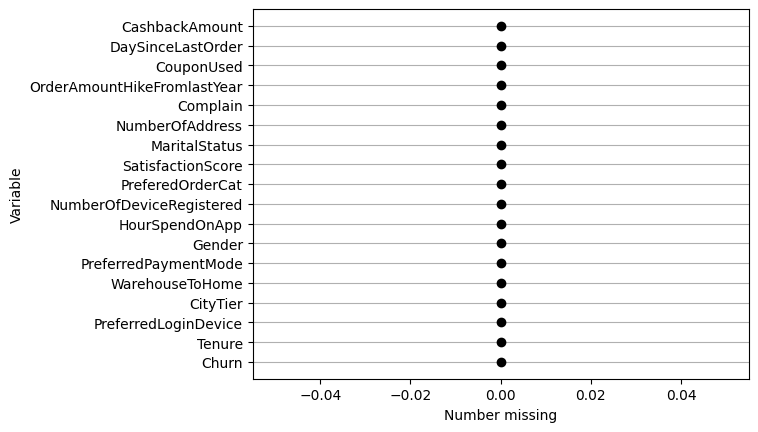

In [17]:
df_cleaned.missing.missing_variable_plot()

In [18]:
import re

def to_snake_case(name):
    # Insert an underscore before any uppercase letter that is not at the start of the string
    name = re.sub(r'(?<!^)(?=[A-Z])', '_', name)
    return name.lower()

df_cleaned.columns = [to_snake_case(col) for col in df_cleaned.columns]

In [19]:
df_cleaned

,churn,tenure,preferred_login_device,city_tier,warehouse_to_home,preferred_payment_mode,gender,hour_spend_on_app,number_of_device_registered,prefered_order_cat,satisfaction_score,marital_status,number_of_address,complain,order_amount_hike_fromlast_year,coupon_used,day_since_last_order,cashback_amount
0,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,5.0,160
1,1,10.0,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,0.0,121
2,1,10.0,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,3.0,120
3,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,3.0,134
4,1,0.0,Phone,1,12.0,CC,Male,3.0,3,Mobile,5,Single,3,0,11.0,1.0,3.0,130
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5625,0,10.0,Computer,1,30.0,Credit Card,Male,3.0,2,Laptop & Accessory,1,Married,6,0,18.0,1.0,4.0,151
5626,0,13.0,Mobile Phone,1,13.0,Credit Card,Male,3.0,5,Fashion,5,Married,6,0,16.0,1.0,5.0,225
5627,0,1.0,Mobile Phone,1,11.0,Debit Card,Male,3.0,2,Laptop & Accessory,4,Married,3,1,21.0,1.0,4.0,186
5628,0,23.0,Computer,3,9.0,Credit Card,Male,4.0,5,Laptop & Accessory,4,Married,4,0,15.0,2.0,9.0,179


In [20]:
df_cleaned.to_csv('ecom_churn_cleaned.csv',index=None)